In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.animation import FuncAnimation, FFMpegWriter
import networkx as nx
from collections import deque
import heapq
import platform
import os

# 한글 폰트 설정 (Windows/Mac/Linux 자동 감지)
def set_korean_font():
    system = platform.system()
    if system == 'Windows':
        plt.rcParams['font.family'] = 'Malgun Gothic'
    elif system == 'Darwin':
        plt.rcParams['font.family'] = 'AppleGothic'
    else:
        for fp in ['/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
                   '/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
                   '/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc']:
            if os.path.exists(fp):
                fm.fontManager.addfont(fp)
                plt.rcParams['font.family'] = fm.FontProperties(fname=fp).get_name()
                break

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False
print(f"운영체제: {platform.system()}, 폰트: {plt.rcParams['font.family']}")

운영체제: Windows, 폰트: ['Malgun Gothic']


## 2. 음식점 및 간선 데이터 (코드 내 하드코딩)

원본 과제 PDF의 지시사항: *"음식점과 이동 시간 정보는 별도의 파일을 만들지 말고 코드 안에 넣는다"*

In [2]:
RESTAURANTS = [
    {'name': '경성고기꾼', 'lat': 37.5913888, 'lng': 127.0162014, 'group': '성신여대'},
    {'name': '멍삼', 'lat': 37.5912197, 'lng': 127.0158899, 'group': '성신여대'},
    {'name': '동경산책', 'lat': 37.590857, 'lng': 127.0179113, 'group': '성신여대'},
    {'name': '벤베누토', 'lat': 37.5927443, 'lng': 127.0185737, 'group': '성신여대'},
    {'name': '렌테이', 'lat': 37.5924948, 'lng': 127.0181612, 'group': '성신여대'},
    {'name': '포썸', 'lat': 37.5941649, 'lng': 127.0182308, 'group': '성신여대'},
    {'name': '상미규카츠', 'lat': 37.5908375, 'lng': 127.0170362, 'group': '성신여대'},
    {'name': '수아당', 'lat': 37.5930715, 'lng': 127.0180342, 'group': '성신여대'},
    {'name': '코지밀', 'lat': 37.5941447, 'lng': 127.0192567, 'group': '성신여대'},
    {'name': '천막집', 'lat': 37.5891021, 'lng': 127.0191188, 'group': '성신여대'},
    {'name': '라라면가', 'lat': 37.5909487, 'lng': 127.0196757, 'group': '성신여대'},
    {'name': '도쿄커틀릿', 'lat': 37.5906561, 'lng': 127.0186563, 'group': '성신여대'},
    {'name': '마라붐', 'lat': 37.5922055, 'lng': 127.0174034, 'group': '성신여대'},
    {'name': '멘야하나비', 'lat': 37.591461, 'lng': 127.0185686, 'group': '성신여대'},
    {'name': '호르몬치치', 'lat': 37.5931093, 'lng': 127.0187533, 'group': '성신여대'},
    {'name': '공푸', 'lat': 37.5888146, 'lng': 127.0161214, 'group': '성신여대'},
    {'name': '김태완스시', 'lat': 37.5911434, 'lng': 127.0166587, 'group': '성신여대'},
    {'name': '이태리맨션', 'lat': 37.5938271, 'lng': 127.0212643, 'group': '성신여대'},
    {'name': '팔백집', 'lat': 37.5894904, 'lng': 127.0198373, 'group': '성신여대'},
    {'name': '짬뽕지존', 'lat': 37.5908052, 'lng': 127.0166862, 'group': '성신여대'},
    {'name': '낙원타코', 'lat': 37.4981375, 'lng': 127.0252957, 'group': '강남역'},
    {'name': '육랩', 'lat': 37.5002366, 'lng': 127.0279973, 'group': '강남역'},
    {'name': '후추포인트', 'lat': 37.5030823, 'lng': 127.0272802, 'group': '강남역'},
    {'name': '도원반점', 'lat': 37.4953441, 'lng': 127.0320369, 'group': '강남역'},
    {'name': '82올리언즈', 'lat': 37.50087, 'lng': 127.0286824, 'group': '강남역'},
    {'name': '빨간의자집', 'lat': 37.5006225, 'lng': 127.0285006, 'group': '강남역'},
    {'name': '쿄코코', 'lat': 37.5033203, 'lng': 127.0274295, 'group': '강남역'},
    {'name': '플랫나인', 'lat': 37.5116067, 'lng': 127.0281274, 'group': '강남역'},
    {'name': '정희', 'lat': 37.5022171, 'lng': 127.0270063, 'group': '강남역'},
    {'name': '고베규카츠', 'lat': 37.5029305, 'lng': 127.0276038, 'group': '강남역'},
    {'name': '흑우정', 'lat': 37.5017694, 'lng': 127.024257, 'group': '강남역'},
    {'name': '서울깍두기', 'lat': 37.4951476, 'lng': 127.0325683, 'group': '강남역'},
    {'name': '봉피양', 'lat': 37.4948012, 'lng': 127.0286234, 'group': '강남역'},
    {'name': '응야끼도리', 'lat': 37.501398, 'lng': 127.0249296, 'group': '강남역'},
    {'name': '진구곱창', 'lat': 37.5007369, 'lng': 127.0247641, 'group': '강남역'},
    {'name': '마초쉐프', 'lat': 37.5035119, 'lng': 127.0278601, 'group': '강남역'},
    {'name': '더막창스', 'lat': 37.5009917, 'lng': 127.0251242, 'group': '강남역'},
    {'name': '을밀대', 'lat': 37.4955423, 'lng': 127.030404, 'group': '강남역'},
    {'name': '강남곱', 'lat': 37.4943735, 'lng': 127.0315686, 'group': '강남역'},
    {'name': '갓덴스시', 'lat': 37.4988358, 'lng': 127.0290056, 'group': '강남역'},
]

print(f'총 음식점 수: {len(RESTAURANTS)}')
print(f'성신여대: {sum(1 for r in RESTAURANTS if r["group"]=="성신여대")}개')
print(f'강남역: {sum(1 for r in RESTAURANTS if r["group"]=="강남역")}개')

총 음식점 수: 40
성신여대: 20개
강남역: 20개


In [3]:
# 간선 60개: (u, v, 자동차 이동시간_분)
EDGES = [
    (25, 29, 2.1),
    (24, 33, 14.2),
    (25, 32, 10.2),
    (25, 38, 7.1),
    (24, 36, 14.5),
    (26, 27, 6.4),
    (26, 39, 3.5),
    (7, 29, 46.9),
    (21, 25, 0.5),
    (29, 32, 11.2),
    (14, 19, 9.2),
    (21, 31, 5.5),
    (18, 38, 52.5),
    (4, 27, 44.4),
    (0, 14, 2.2),
    (3, 37, 52.4),
    (2, 8, 2.3),
    (11, 17, 2.3),
    (5, 37, 57.4),
    (30, 33, 0.6),
    (8, 33, 47.6),
    (16, 19, 1.0),
    (11, 38, 53.2),
    (18, 19, 4.9),
    (32, 36, 6.3),
    (4, 8, 1.5),
    (12, 15, 6.8),
    (29, 37, 7.0),
    (23, 33, 12.4),
    (22, 31, 6.1),
    (10, 11, 0.8),
    (9, 13, 1.6),
    (0, 16, 0.3),
    (36, 39, 10.7),
    (0, 13, 3.3),
    (2, 10, 1.1),
    (11, 19, 4.8),
    (13, 16, 4.9),
    (27, 30, 10.3),
    (2, 19, 5.2),
    (30, 35, 5.3),
    (24, 28, 1.7),
    (16, 18, 3.3),
    (7, 15, 5.6),
    (24, 31, 5.7),
    (26, 28, 1.0),
    (35, 37, 7.6),
    (25, 30, 9.5),
    (15, 28, 44.1),
    (26, 37, 7.3),
    (3, 14, 0.4),
    (5, 11, 6.8),
    (22, 30, 8.8),
    (0, 3, 2.6),
    (22, 33, 9.3),
    (0, 6, 5.3),
    (20, 39, 12.0),
    (1, 13, 2.8),
    (4, 34, 50.2),
    (3, 38, 54.7),
]

print(f'총 간선 수: {len(EDGES)}')
weights = [w for _, _, w in EDGES]
print(f'이동시간: 최소 {min(weights):.1f}분, 최대 {max(weights):.1f}분, 평균 {sum(weights)/len(weights):.1f}분')

총 간선 수: 60
이동시간: 최소 0.3분, 최대 57.4분, 평균 13.0분


## 3. 그래프 구성

In [4]:
# 그래프 생성
G = nx.Graph()
for i, r in enumerate(RESTAURANTS):
    G.add_node(i, name=r['name'], group=r['group'])
for u, v, w in EDGES:
    G.add_edge(u, v, weight=w)

# 보조 딕셔너리
GEO_POS = {i: (r['lng'], r['lat']) for i, r in enumerate(RESTAURANTS)}
NAMES = {i: r['name'] for i, r in enumerate(RESTAURANTS)}
GROUPS = {i: r['group'] for i, r in enumerate(RESTAURANTS)}

# 좌표 배치: 클러스터별로 spring_layout 후 좌상단/우하단으로 분리
import numpy as np

def cluster_layout(G, groups, seed=42):
    G_seongshin = G.subgraph([i for i in G.nodes if groups[i] == '성신여대'])
    G_gangnam = G.subgraph([i for i in G.nodes if groups[i] == '강남역'])
    pos_s = nx.spring_layout(G_seongshin, k=0.5, iterations=80, seed=seed)
    pos_g = nx.spring_layout(G_gangnam, k=0.5, iterations=80, seed=seed)

    def normalize_and_shift(pos, center, scale=0.4):
        if not pos:
            return {}
        coords = np.array(list(pos.values()))
        coords = (coords - coords.mean(axis=0)) / (coords.std(axis=0) + 1e-8) * scale
        return {n: (coords[i][0] + center[0], coords[i][1] + center[1]) for i, n in enumerate(pos.keys())}

    pos_s = normalize_and_shift(pos_s, center=(-1.2, 1.0))  # 좌상단 (성신여대)
    pos_g = normalize_and_shift(pos_g, center=(1.2, -1.0))  # 우하단 (강남역)
    return {**pos_s, **pos_g}

POS = cluster_layout(G, GROUPS, seed=42)

print(f'노드 수: {G.number_of_nodes()}')
print(f'간선 수: {G.number_of_edges()}')
print(f'연결 그래프: {nx.is_connected(G)}')
print(f'평균 차수: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}')

노드 수: 40
간선 수: 60
연결 그래프: True
평균 차수: 3.00


## 4. 그래프 시각화

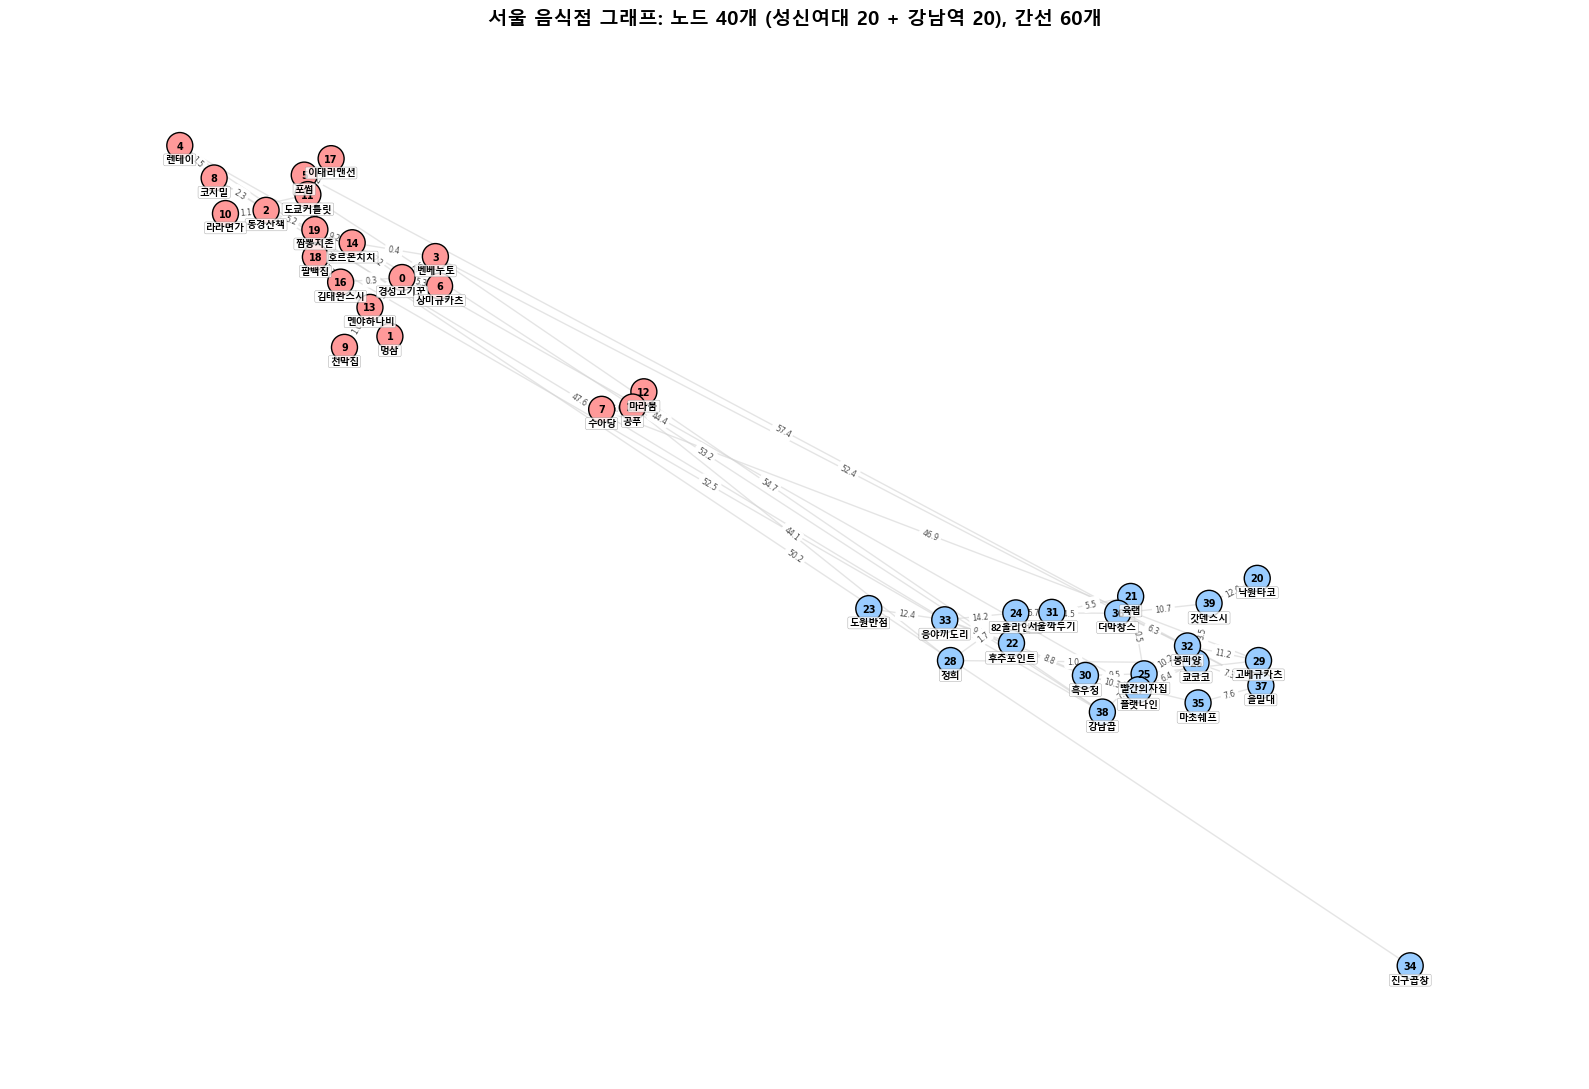

✓ graph_overview.png 저장 완료


In [5]:
def draw_base_graph(ax, G, pos, names, groups, with_labels=True):
    """기본 그래프 그리기 (재사용)"""
    ys = [p[1] for p in pos.values()]
    y_range = max(ys) - min(ys)
    dy = y_range * 0.012

    # 간선
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='lightgray', width=1, alpha=0.6)

    # 가중치 라벨
    edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                  font_size=5.5, alpha=0.7)

    # 노드: 그룹별 색상
    node_colors = ['#FF9999' if groups[i] == '성신여대' else '#99CCFF' for i in G.nodes()]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                            node_size=350, edgecolors='black', linewidths=1)

    # 노드 번호
    nx.draw_networkx_labels(G, pos, labels={i: str(i) for i in G.nodes()},
                             ax=ax, font_size=7, font_weight='bold')

    # 음식점 이름 (노드 아래)
    if with_labels:
        for idx, name in names.items():
            x, y = pos[idx]
            ax.text(x, y - dy, name, fontsize=7, ha='center', va='top',
                    fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='gray', alpha=0.8, linewidth=0.3))

fig, ax = plt.subplots(figsize=(16, 11))
draw_base_graph(ax, G, POS, NAMES, GROUPS)
ax.set_title('서울 음식점 그래프: 노드 40개 (성신여대 20 + 강남역 20), 간선 60개',
              fontsize=14, fontweight='bold')
ax.axis('off')
ax.margins(0.08, 0.08)
plt.tight_layout()
plt.savefig('graph_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ graph_overview.png 저장 완료')

## 5. DFS (깊이 우선 탐색)

In [6]:
def dfs_steps(G, start=0):
    """DFS의 각 단계를 기록 (스택 기반)"""
    steps = []
    visited = set()
    visit_order = []  # 방문 순서 (번호 배지용)
    tree_edges = []
    stack = [(start, None)]

    while stack:
        u, parent = stack.pop()
        if u in visited:
            continue
        visited.add(u)
        visit_order.append(u)
        if parent is not None:
            tree_edges.append((parent, u))
        msg = f'시작: {NAMES[u]}' if parent is None else f'방문: {NAMES[parent]} → {NAMES[u]}'
        steps.append({
            'visited': set(visited),
            'order': list(visit_order),
            'tree': list(tree_edges),
            'current': u,
            'msg': msg
        })
        neighbors = sorted(G.neighbors(u), reverse=True)
        for nb in neighbors:
            if nb not in visited:
                stack.append((nb, u))
    return steps

dfs_record = dfs_steps(G, start=0)
print(f'DFS 단계 수: {len(dfs_record)}')
print(f'방문 순서: {[step["current"] for step in dfs_record]}')

DFS 단계 수: 40
방문 순서: [0, 3, 14, 19, 2, 8, 4, 27, 26, 28, 15, 7, 29, 25, 21, 31, 22, 30, 33, 23, 24, 36, 32, 39, 20, 35, 37, 5, 11, 10, 17, 38, 18, 16, 13, 1, 9, 12, 34, 6]


## 5-1. DFS 애니메이션

In [7]:
def draw_node_labels_offset(ax, labels, pos, dy=0.0008, font_size=8):
    """노드 라벨을 노드 약간 아래에 그려서 노드 위 글씨 잘림 방지"""
    for idx, label in labels.items():
        x, y = pos[idx]
        ax.text(x, y - dy, label, fontsize=font_size, ha='center', va='top',
                fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='gray', alpha=0.8, linewidth=0.3))

def draw_visit_badges(ax, order, pos, badge_color='#FB8C00', current=None):
    """방문 순서 번호를 노드 우측 상단에 작은 원형 배지로 표시"""
    for i, node in enumerate(order, 1):
        x, y = pos[node]
        bcolor = '#E53935' if node == current else badge_color
        ax.text(x + 0.0015, y + 0.0015, str(i),
                fontsize=6, color='white', fontweight='bold',
                ha='center', va='center', zorder=10,
                bbox=dict(boxstyle='circle,pad=0.15',
                          facecolor=bcolor, edgecolor='white', linewidth=0.8))

def make_traversal_animation(steps, title_prefix, filename, fps=2, show_queue=False):
    """DFS/BFS 탐색 과정을 애니메이션으로 저장
    
    Args:
        show_queue: True이면 하단에 현재 큐 상태 표시 (BFS용)
    """
    fig, ax = plt.subplots(figsize=(16, 11))

    ys = [p[1] for p in POS.values()]
    y_range = max(ys) - min(ys)
    dy = y_range * 0.012

    def update(frame):
        ax.clear()
        s = steps[frame]
        nx.draw_networkx_edges(G, POS, ax=ax, edge_color='lightgray', alpha=0.4, width=1)
        if s['tree']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=s['tree'],
                                    edge_color='#1E88E5', width=3, alpha=0.9)
        node_colors = []
        for i in G.nodes():
            if i == s['current']:
                node_colors.append('#E53935')
            elif i in s['visited']:
                node_colors.append('#FB8C00')
            else:
                node_colors.append('#FFCDD2' if GROUPS[i] == '성신여대' else '#B2DFDB')
        nx.draw_networkx_nodes(G, POS, ax=ax, node_color=node_colors, node_size=350,
                                edgecolors='black', linewidths=1)
        nx.draw_networkx_labels(G, POS, labels={i: str(i) for i in G.nodes()},
                                 ax=ax, font_size=7, font_weight='bold')
        draw_node_labels_offset(ax, NAMES, POS, dy=dy, font_size=7)
        # 방문 순서 배지
        draw_visit_badges(ax, s['order'], POS, current=s['current'])

        ax.set_title(f"{title_prefix} - Step {frame+1}/{len(steps)} | {s['msg']} | 방문: {len(s['visited'])}/40",
                      fontsize=13, fontweight='bold')
        ax.axis('off')
        ax.margins(0.08, 0.08)

        # BFS: 하단에 현재 큐 상태 표시
        if show_queue and 'queue' in s:
            q = s['queue']
            if q:
                queue_str = ' → '.join([NAMES[i] for i in q[:8]])
                if len(q) > 8:
                    queue_str += f' ... (총 {len(q)}개)'
                ax.text(0.5, -0.02, f'큐: [ {queue_str} ]',
                        transform=ax.transAxes, ha='center', va='top',
                        fontsize=10, fontweight='bold', color='#1565C0',
                        bbox=dict(boxstyle='round,pad=0.4', facecolor='#E3F2FD',
                                  edgecolor='#1565C0', linewidth=1))
            else:
                ax.text(0.5, -0.02, '큐: [ (비어있음) ]',
                        transform=ax.transAxes, ha='center', va='top',
                        fontsize=10, fontweight='bold', color='gray')

    anim = FuncAnimation(fig, update, frames=len(steps), interval=1000//fps, repeat=False)
    writer = FFMpegWriter(fps=fps, bitrate=2400)
    anim.save(filename, writer=writer, dpi=100)
    plt.close()
    print(f'✓ {filename} 저장 완료 ({len(steps)} 프레임)')

make_traversal_animation(dfs_record, 'DFS (깊이 우선 탐색)', 'dfs.mp4', fps=2, show_queue=False)

✓ dfs.mp4 저장 완료 (40 프레임)


## 6. BFS (너비 우선 탐색)

In [8]:
def bfs_steps(G, start=0):
    """BFS의 각 단계를 기록 (큐 기반)"""
    steps = []
    visited = {start}
    visit_order = [start]
    tree_edges = []
    queue = deque([start])
    steps.append({
        'visited': set(visited),
        'order': list(visit_order),
        'tree': list(tree_edges),
        'current': start,
        'queue': list(queue),
        'msg': f'시작: {NAMES[start]}'
    })
    while queue:
        u = queue.popleft()
        for nb in sorted(G.neighbors(u)):
            if nb not in visited:
                visited.add(nb)
                visit_order.append(nb)
                tree_edges.append((u, nb))
                queue.append(nb)
                steps.append({
                    'visited': set(visited),
                    'order': list(visit_order),
                    'tree': list(tree_edges),
                    'current': nb,
                    'queue': list(queue),
                    'msg': f'방문: {NAMES[u]} → {NAMES[nb]}'
                })
    return steps

bfs_record = bfs_steps(G, start=0)
print(f'BFS 단계 수: {len(bfs_record)}')
print(f'방문 순서: {[step["current"] for step in bfs_record]}')

BFS 단계 수: 40
방문 순서: [0, 3, 6, 13, 14, 16, 37, 38, 1, 9, 19, 18, 5, 26, 29, 35, 11, 25, 2, 27, 28, 39, 7, 32, 30, 10, 17, 21, 8, 4, 15, 24, 20, 36, 22, 33, 31, 34, 12, 23]


## 6-1. BFS 애니메이션 (큐 상태 표시 포함)

In [9]:
make_traversal_animation(bfs_record, 'BFS (너비 우선 탐색)', 'bfs.mp4', fps=2, show_queue=True)

✓ bfs.mp4 저장 완료 (40 프레임)


## 7. Prim 알고리즘 (최소 신장 트리)

In [10]:
def prim_steps(G, start=0):
    """Prim 알고리즘의 각 단계를 기록"""
    steps = []
    in_mst = {start}
    mst_edges = []
    heap = []
    for nb in G.neighbors(start):
        heapq.heappush(heap, (G[start][nb]['weight'], start, nb))

    steps.append({
        'in_mst': set(in_mst),
        'mst_edges': [],
        'candidate_edges': [(u, v) for _, u, v in heap],
        'current_edge': None,
        'msg': f'시작 노드: {NAMES[start]}'
    })

    while heap and len(in_mst) < G.number_of_nodes():
        w, u, v = heapq.heappop(heap)
        if v in in_mst:
            continue
        in_mst.add(v)
        mst_edges.append((u, v))
        for nb in G.neighbors(v):
            if nb not in in_mst:
                heapq.heappush(heap, (G[v][nb]['weight'], v, nb))
        steps.append({
            'in_mst': set(in_mst),
            'mst_edges': list(mst_edges),
            'candidate_edges': [(uu, vv) for _, uu, vv in heap if vv not in in_mst],
            'current_edge': (u, v),
            'msg': f'추가: {NAMES[u]} → {NAMES[v]} ({w:.1f}분)'
        })
    return steps

prim_record = prim_steps(G, start=0)
prim_total = sum(G[u][v]['weight'] for u, v in prim_record[-1]['mst_edges'])
print(f'Prim 단계 수: {len(prim_record)}')
print(f'MST 간선 수: {len(prim_record[-1]["mst_edges"])}')
print(f'MST 총 가중치: {prim_total:.2f}분')

Prim 단계 수: 40
MST 간선 수: 39
MST 총 가중치: 291.90분


## 7-1. Prim 애니메이션

In [11]:
def make_prim_animation(steps, filename, fps=3):
    fig, ax = plt.subplots(figsize=(16, 11))
    ys = [p[1] for p in POS.values()]
    y_range = max(ys) - min(ys)
    dy = y_range * 0.012

    def update(frame):
        ax.clear()
        s = steps[frame]
        # 모든 간선 (옅게)
        nx.draw_networkx_edges(G, POS, ax=ax, edge_color='lightgray', alpha=0.3, width=1)
        # 후보 간선 (Prim heap에 있는 것)
        if s['candidate_edges']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=s['candidate_edges'],
                                    edge_color='#FFC107', width=1.5, alpha=0.6,
                                    style='dashed')
        # MST 간선
        if s['mst_edges']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=s['mst_edges'],
                                    edge_color='#2E7D32', width=3.5, alpha=0.95)
        # 현재 선택된 간선
        if s['current_edge']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=[s['current_edge']],
                                    edge_color='#E53935', width=4, alpha=0.95)
        # 노드 색상
        node_colors = []
        for i in G.nodes():
            if i in s['in_mst']:
                node_colors.append('#66BB6A')
            else:
                node_colors.append('#FFCDD2' if GROUPS[i] == '성신여대' else '#B2DFDB')
        nx.draw_networkx_nodes(G, POS, ax=ax, node_color=node_colors, node_size=350,
                                edgecolors='black', linewidths=1)
        nx.draw_networkx_labels(G, POS, labels={i: str(i) for i in G.nodes()},
                                 ax=ax, font_size=7, font_weight='bold')
        for idx, name in NAMES.items():
            x, y = POS[idx]
            ax.text(x, y - dy, name, fontsize=7, ha='center', va='top', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='gray', alpha=0.8, linewidth=0.3))

        total = sum(G[u][v]['weight'] for u, v in s['mst_edges']) if s['mst_edges'] else 0
        ax.set_title(f"Prim 알고리즘 - Step {frame+1}/{len(steps)} | {s['msg']}\nMST 노드: {len(s['in_mst'])}/40 | MST 합: {total:.1f}분",
                      fontsize=12, fontweight='bold')
        ax.axis('off')
        ax.margins(0.08, 0.08)

    anim = FuncAnimation(fig, update, frames=len(steps), interval=1000//fps, repeat=False)
    writer = FFMpegWriter(fps=fps, bitrate=2400)
    anim.save(filename, writer=writer, dpi=100)
    plt.close()
    print(f'✓ {filename} 저장 완료')

make_prim_animation(prim_record, 'prim.mp4', fps=3)

✓ prim.mp4 저장 완료


## 8. Kruskal 알고리즘 (최소 신장 트리)

In [12]:
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return False
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1
        return True
    def components(self):
        return [self.find(i) for i in range(len(self.parent))]

def kruskal_steps(G):
    """Kruskal 알고리즘의 각 단계를 기록"""
    steps = []
    n = G.number_of_nodes()
    uf = UnionFind(n)
    edges_sorted = sorted(G.edges(data=True), key=lambda e: e[2]['weight'])
    # 정렬된 간선 정보 저장 (사이드바용)
    edges_info = [(u, v, d['weight']) for u, v, d in edges_sorted]
    mst_edges = []
    rejected_edges = []

    steps.append({
        'mst': [],
        'rejected': [],
        'current_edge': None,
        'current_idx': -1,
        'accepted': None,
        'components': uf.components(),
        'msg': f'간선 {len(edges_sorted)}개 가중치 순 정렬 완료'
    })

    for idx, (u, v, d) in enumerate(edges_sorted):
        w = d['weight']
        accepted = uf.union(u, v)
        if accepted:
            mst_edges.append((u, v))
            msg = f'추가: {NAMES[u]} ↔ {NAMES[v]} ({w:.1f}분)'
        else:
            rejected_edges.append((u, v))
            msg = f'거부 (사이클): {NAMES[u]} ↔ {NAMES[v]} ({w:.1f}분)'
        steps.append({
            'mst': list(mst_edges),
            'rejected': list(rejected_edges),
            'current_edge': (u, v),
            'current_idx': idx,
            'accepted': accepted,
            'components': uf.components(),
            'msg': msg
        })
        if len(mst_edges) == n - 1:
            break
    return steps, edges_info

kruskal_record, kruskal_edges_info = kruskal_steps(G)
kruskal_total = sum(G[u][v]['weight'] for u, v in kruskal_record[-1]['mst'])
print(f'Kruskal 단계 수: {len(kruskal_record)}')
print(f'MST 간선 수: {len(kruskal_record[-1]["mst"])}')
print(f'MST 총 가중치: {kruskal_total:.2f}분')
print(f'Prim 결과와 일치: {abs(kruskal_total - prim_total) < 1e-6}')

Kruskal 단계 수: 56
MST 간선 수: 39
MST 총 가중치: 291.90분
Prim 결과와 일치: True


## 8-1. Kruskal 애니메이션 (정렬된 간선 리스트 사이드바 포함)

In [ ]:
def make_kruskal_animation(steps, edges_info, filename, fps=3):
    # 사이드바를 위해 1x2 subplot
    fig, (ax, ax_side) = plt.subplots(1, 2, figsize=(20, 11),
                                       gridspec_kw={'width_ratios': [4, 1]})

    ys = [p[1] for p in POS.values()]
    y_range = max(ys) - min(ys)
    dy = y_range * 0.012

    # 컴포넌트별 색상 팔레트
    import matplotlib.cm as cm
    palette = list(cm.tab20.colors) + list(cm.tab20b.colors)

    def update(frame):
        ax.clear()
        ax_side.clear()
        s = steps[frame]

        # 메인 그래프
        nx.draw_networkx_edges(G, POS, ax=ax, edge_color='lightgray', alpha=0.3, width=1)
        if s['rejected']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=s['rejected'],
                                    edge_color='#E53935', width=1.2, style='dashed', alpha=0.5)
        if s['mst']:
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=s['mst'],
                                    edge_color='#2E7D32', width=3.5, alpha=0.95)
        if s['current_edge']:
            color = '#1E88E5' if s.get('accepted') else '#E53935'
            nx.draw_networkx_edges(G, POS, ax=ax, edgelist=[s['current_edge']],
                                    edge_color=color, width=4, alpha=0.95)

        comp_map = {}
        node_colors = []
        for i, root in enumerate(s['components']):
            if root not in comp_map:
                comp_map[root] = palette[len(comp_map) % len(palette)]
            node_colors.append(comp_map[root])
        nx.draw_networkx_nodes(G, POS, ax=ax, node_color=node_colors, node_size=350,
                                edgecolors='black', linewidths=1)
        nx.draw_networkx_labels(G, POS, labels={i: str(i) for i in G.nodes()},
                                 ax=ax, font_size=7, font_weight='bold')
        for idx, name in NAMES.items():
            x, y = POS[idx]
            ax.text(x, y - dy, name, fontsize=7, ha='center', va='top', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='gray', alpha=0.8, linewidth=0.3))

        total = sum(G[u][v]['weight'] for u, v in s['mst']) if s['mst'] else 0
        num_comp = len(set(s['components']))
        ax.set_title(f"Kruskal 알고리즘 - Step {frame+1}/{len(steps)} | {s['msg']}\nMST 합: {total:.1f}분 | 컴포넌트 수: {num_comp}",
                      fontsize=12, fontweight='bold')
        ax.axis('off')
        ax.margins(0.08, 0.08)

        # 사이드바: 정렬된 간선 리스트
        ax_side.set_xlim(0, 1)
        ax_side.set_ylim(0, 1)
        ax_side.axis('off')
        ax_side.text(0.5, 0.98, '─ 가중치 정렬 순서 ─',
                     ha='center', va='top', fontsize=11, fontweight='bold')

        cur_idx = s.get('current_idx', -1)
        # 현재 검토 중인 간선 주변만 (스크롤 효과)
        n_show = 25
        start_idx = max(0, cur_idx - 8)
        end_idx = min(len(edges_info), start_idx + n_show)
        mst_set = set()
        for u, v in s['mst']:
            mst_set.add((u, v))
            mst_set.add((v, u))

        y_pos = 0.94
        for i in range(start_idx, end_idx):
            u, v, w = edges_info[i]
            is_current = (i == cur_idx)
            in_mst = (u, v) in mst_set or (v, u) in mst_set

            if is_current:
                if s.get('accepted'):
                    prefix = '▶ '
                    color = '#1E88E5'
                    fw = 'bold'
                else:
                    prefix = '✗ '
                    color = '#E53935'
                    fw = 'bold'
            elif in_mst:
                prefix = '✓ '
                color = '#2E7D32'
                fw = 'normal'
            elif i < cur_idx:
                prefix = '· '
                color = '#999999'
                fw = 'normal'
            else:
                prefix = '  '
                color = '#555555'
                fw = 'normal'

            label = f'{prefix}#{i+1:02d} {NAMES[u][:5]}↔{NAMES[v][:5]} {w:.1f}m'
            ax_side.text(0.05, y_pos, label,
                         ha='left', va='top', fontsize=8,
                         color=color, fontweight=fw)
            y_pos -= 0.034

    anim = FuncAnimation(fig, update, frames=len(steps), interval=1000//fps, repeat=False)
    writer = FFMpegWriter(fps=fps, bitrate=2400)
    anim.save(filename, writer=writer, dpi=100)
    plt.close()
    print(f'✓ {filename} 저장 완료')

make_kruskal_animation(kruskal_record, kruskal_edges_info, 'kruskal.mp4', fps=3)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27920\637825657.py:109: UserWarning: Glyph 44221 (\N{HANGUL SYLLABLE GYEONG}) missing from font(s) DejaVu Sans Mono.
  anim.save(filename, writer=writer, dpi=100)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27920\637825657.py:109: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans Mono.
  anim.save(filename, writer=writer, dpi=100)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27920\637825657.py:109: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans Mono.
  anim.save(filename, writer=writer, dpi=100)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27920\637825657.py:109: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans Mono.
  anim.save(filename, writer=writer, dpi=100)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_27920\637825657.py:109: UserWarning: Glyph 44988 (\N{HANGUL SYLLABLE GGUN}) m

✓ kruskal.mp4 저장 완료


## 9. 결과 요약

In [14]:
print('=' * 50)
print('Assignment 09 결과 요약')
print('=' * 50)
print(f'그래프: 노드 {G.number_of_nodes()}개, 간선 {G.number_of_edges()}개')
print(f'  - 성신여대 지역: {sum(1 for i in G.nodes if GROUPS[i]=="성신여대")}개')
print(f'  - 강남역 지역: {sum(1 for i in G.nodes if GROUPS[i]=="강남역")}개')
print(f'  - 연결 그래프: {nx.is_connected(G)}')
print()
print(f'DFS: 시작={NAMES[0]}, 모든 음식점 방문 ({len(dfs_record)} 단계)')
print(f'BFS: 시작={NAMES[0]}, 모든 음식점 방문 ({len(bfs_record)} 단계)')
print()
print(f'Prim MST: {len(prim_record[-1]["mst_edges"])}개 간선, 총 {prim_total:.2f}분')
print(f'Kruskal MST: {len(kruskal_record[-1]["mst"])}개 간선, 총 {kruskal_total:.2f}분')
print(f'두 MST 결과 일치: {abs(prim_total - kruskal_total) < 1e-6}')
print()
print('생성된 파일:')
for f in ['graph_overview.png', 'dfs.mp4', 'bfs.mp4', 'prim.mp4', 'kruskal.mp4']:
    exists = '✓' if os.path.exists(f) else '✗'
    print(f'  {exists} {f}')

Assignment 09 결과 요약
그래프: 노드 40개, 간선 60개
  - 성신여대 지역: 20개
  - 강남역 지역: 20개
  - 연결 그래프: True

DFS: 시작=경성고기꾼, 모든 음식점 방문 (40 단계)
BFS: 시작=경성고기꾼, 모든 음식점 방문 (40 단계)

Prim MST: 39개 간선, 총 291.90분
Kruskal MST: 39개 간선, 총 291.90분
두 MST 결과 일치: True

생성된 파일:
  ✓ graph_overview.png
  ✓ dfs.mp4
  ✓ bfs.mp4
  ✓ prim.mp4
  ✓ kruskal.mp4


## 10. Prim vs Kruskal MST 비교

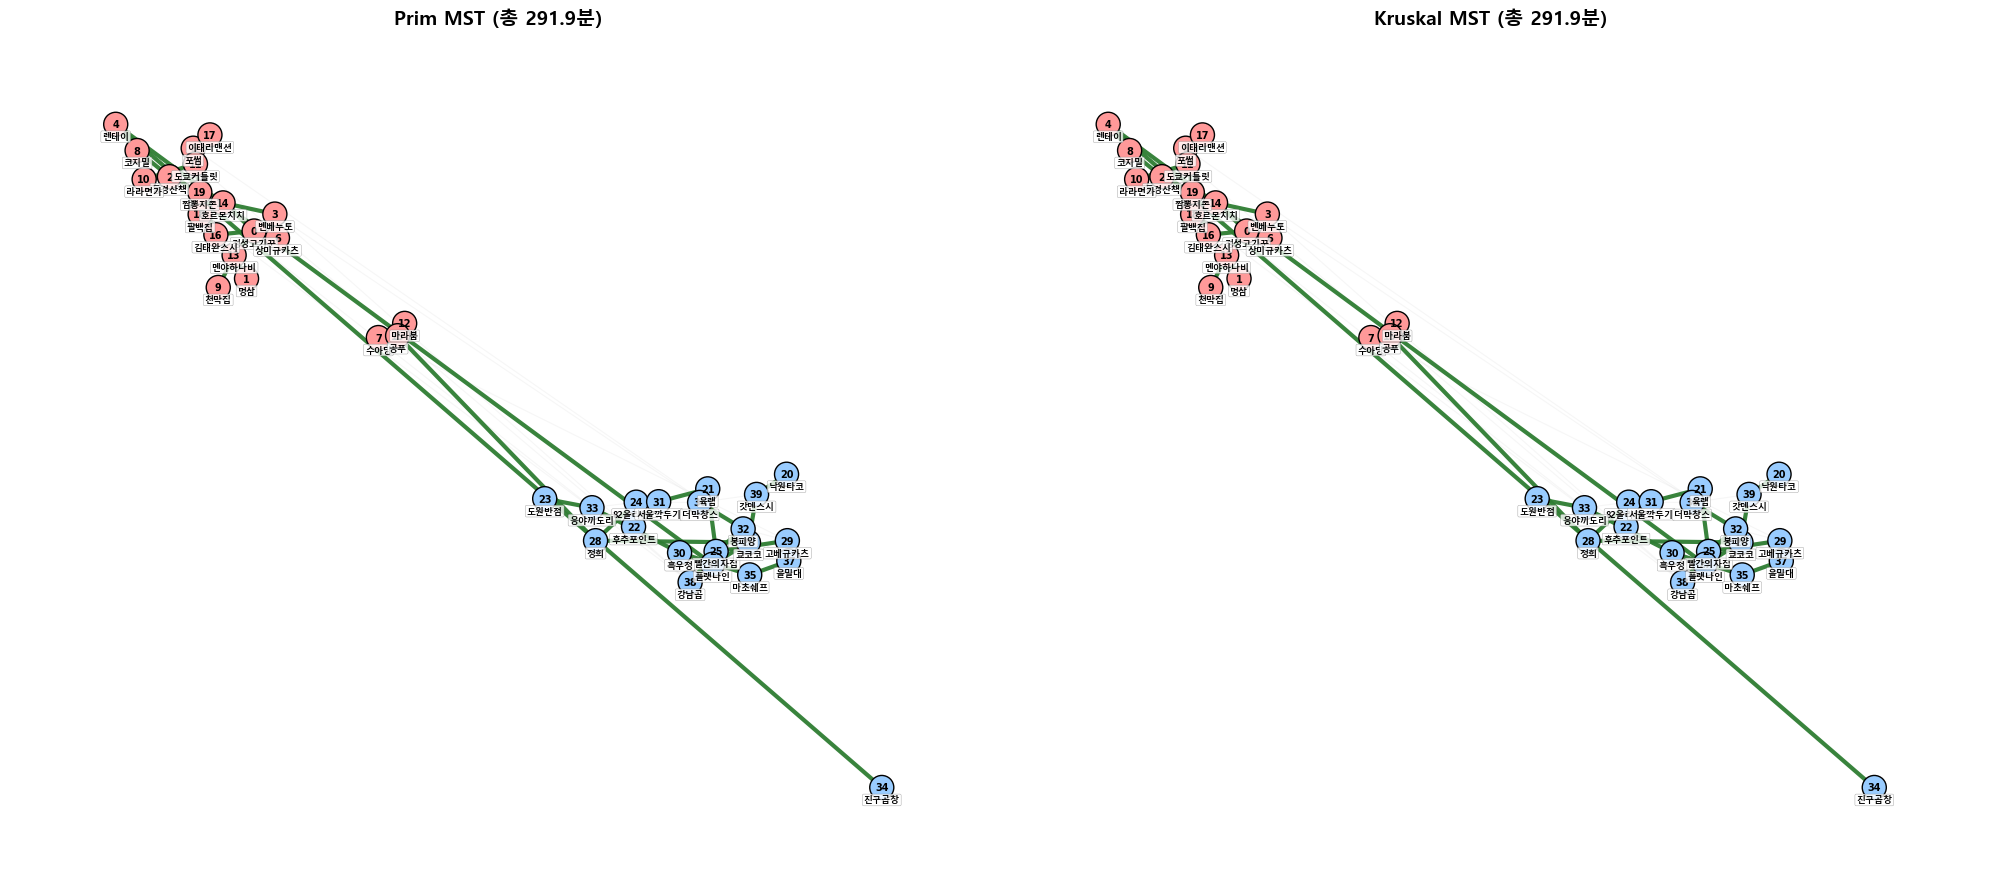

✓ mst_comparison.png 저장 완료


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
ys = [p[1] for p in POS.values()]
y_range = max(ys) - min(ys)
dy = y_range * 0.012

for ax, mst_edges, title in [
    (axes[0], prim_record[-1]['mst_edges'], f'Prim MST (총 {prim_total:.1f}분)'),
    (axes[1], kruskal_record[-1]['mst'], f'Kruskal MST (총 {kruskal_total:.1f}분)')
]:
    nx.draw_networkx_edges(G, POS, ax=ax, edge_color='lightgray', alpha=0.2, width=0.8)
    nx.draw_networkx_edges(G, POS, ax=ax, edgelist=mst_edges,
                            edge_color='#2E7D32', width=3, alpha=0.95)
    node_colors = ['#FF9999' if GROUPS[i] == '성신여대' else '#99CCFF' for i in G.nodes()]
    nx.draw_networkx_nodes(G, POS, ax=ax, node_color=node_colors, node_size=300,
                            edgecolors='black', linewidths=1)
    nx.draw_networkx_labels(G, POS, labels={i: str(i) for i in G.nodes()},
                             ax=ax, font_size=7, font_weight='bold')
    for idx, name in NAMES.items():
        x, y = POS[idx]
        ax.text(x, y - dy, name, fontsize=6.5, ha='center', va='top', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                          edgecolor='gray', alpha=0.8, linewidth=0.3))
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    ax.margins(0.08, 0.08)

plt.tight_layout()
plt.savefig('mst_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ mst_comparison.png 저장 완료')

---
## 과제 결과물

| 항목 | 파일명 |
|------|--------|
| 그래프 시각화 | `graph_overview.png` |
| DFS 애니메이션 | `dfs.mp4` |
| BFS 애니메이션 | `bfs.mp4` |
| Prim 애니메이션 | `prim.mp4` |
| Kruskal 애니메이션 | `kruskal.mp4` |
| MST 비교 | `mst_comparison.png` |
| 본 노트북 | `Assignment_09_Graph.ipynb` |